In [2]:
import pandas as pd
import os
import requests
import json

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [6]:
from preprocessing_utils import preprocess_NVD_data

In [7]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

### <font color='blue'><b><i>TODO</i></b></font>:
- in the following cell, replace `epss_scores-2025-09-30.csv.gz` with the correct updated file (`epss_scores-2025-10-01.csv.gz`)

In [36]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)
epss_current # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01141,0.77780
1,CVE-1999-0002,0.10742,0.93087
2,CVE-1999-0003,0.90362,0.99589
3,CVE-1999-0004,0.03215,0.86596
4,CVE-1999-0005,0.25334,0.96035
...,...,...,...
296328,CVE-2025-9994,0.00060,0.19138
296329,CVE-2025-9996,0.00179,0.40027
296330,CVE-2025-9997,0.00182,0.40386
296331,CVE-2025-9998,0.00023,0.04753


# NVD data

In [37]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1 

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)

1000
2000
3000
4000
5000


In [38]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [39]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)
    
# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [40]:
df.head(100).T

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
cve.id,CVE-2025-9751,CVE-2025-9752,CVE-2025-9753,CVE-2025-9754,CVE-2025-9755,CVE-2025-9756,CVE-2025-9567,CVE-2025-9568,CVE-2025-9569,CVE-2025-9757,...,CVE-2025-9806,CVE-2025-8662,CVE-2025-9811,CVE-2025-9812,CVE-2025-9813,CVE-2025-9814,CVE-2025-9815,CVE-2025-41690,CVE-2025-44017,CVE-2025-41030
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,twcert@cert.org.tw,twcert@cert.org.tw,twcert@cert.org.tw,cna@vuldb.com,...,cna@vuldb.com,37c6977f-aa3f-41e8-829b-3e8ff4df3c14,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,info@cert.vde.com,vultures@jpcert.or.jp,cve-coordination@incibe.es
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000,2025-09-01 01:15:47.060000,2025-09-01 02:15:45.223000,2025-09-01 02:15:45.493000,2025-09-01 02:15:45.713000,2025-09-01 03:15:32.337000,2025-09-01 03:15:32.570000,2025-09-01 03:15:32.767000,2025-09-01 03:15:32.967000,...,2025-09-02 01:15:30.957000,2025-09-02 03:15:42.747000,2025-09-02 03:15:42.930000,2025-09-02 03:15:43.153000,2025-09-02 05:15:39.480000,2025-09-02 05:15:39.743000,2025-09-02 05:15:39.967000,2025-09-02 08:15:30.583000,2025-09-02 08:15:30.977000,2025-09-02 09:15:33.170000
cve.lastModified,2026-06-17 10:09:40.847000,2026-06-17 10:09:40.990000,2026-06-17 10:09:41.133000,2026-06-17 10:09:41.280000,2026-06-17 10:09:41.413000,2026-06-17 10:09:41.557000,2026-06-17 10:09:16.733000,2026-06-17 10:09:16.860000,2026-06-17 10:09:16.980000,2026-06-17 10:09:41.693000,...,2026-06-17 10:09:48.633000,2026-06-17 10:07:24.100000,2026-06-17 10:09:49.223000,2026-06-17 10:09:49.360000,2026-06-17 10:09:49.497000,2026-06-17 10:09:49.630000,2026-06-17 10:09:49.767000,2026-06-17 09:22:57.920000,2026-06-17 09:24:55.560000,2026-06-17 09:22:27.390000
cve.vulnStatus,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,...,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Analyzed,Deferred,Deferred,Deferred
cve.affected,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'twcert@cert.org.tw', 'affectedDat...","[{'source': 'twcert@cert.org.tw', 'affectedDat...","[{'source': 'twcert@cert.org.tw', 'affectedDat...","[{'source': 'cna@vuldb.com', 'affectedData': [...",...,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '37c6977f-aa3f-41e8-829b-3e8ff4df3...,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'info@cert.vde.com', 'affectedData...","[{'source': 'vultures@jpcert.or.jp', 'affected...","[{'source': 'cve-coordination@incibe.es', 'aff..."
cve.metrics.ssvcV203,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b

- show a bar plot with the daily volume of published CVEs

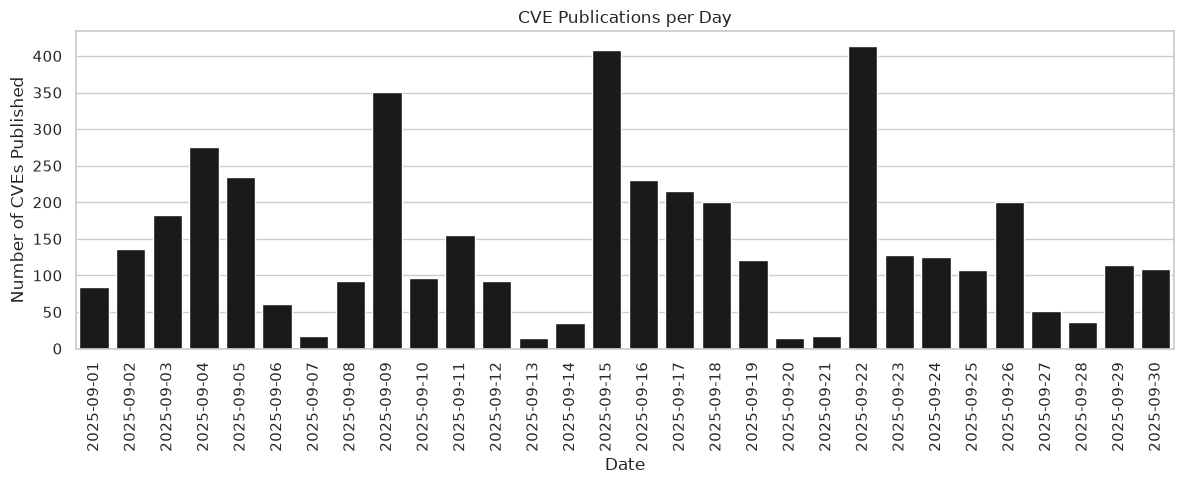

In [41]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

In [42]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2026-06-17 10:09:40.847000,2026-06-17 10:09:40.990000
cve.vulnStatus,Analyzed,Analyzed
cve.affected,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [..."
cve.metrics.ssvcV203,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN


- print the description of the last ten published vulnerabilities

In [43]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV? 
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

### What is the percentage of CVEs which received a CVSS score?

In [44]:
n_with_cvss = df["cvss_baseScore"].notna().sum()
n_total = len(df)
pct_with_cvss = n_with_cvss / n_total * 100

print(f"CVE with CVSS score: {n_with_cvss} su {n_total} ({pct_with_cvss:.1f}%)")

CVE with CVSS score: 4160 su 4320 (96.3%)


### Report descriptive statistics of CVSS the CVSS base score and/or show its distribution

CVSS base score statistics:
count    4160.000000
mean        6.770986
std         1.715107
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64


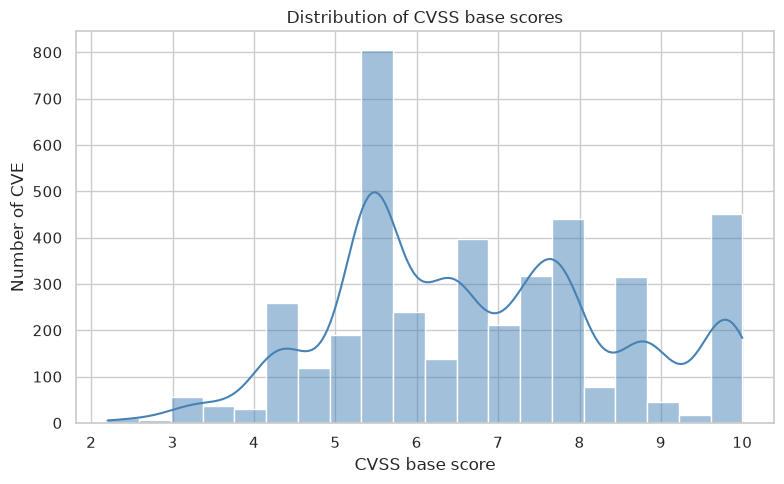

In [45]:
print("CVSS base score statistics:")
print(df["cvss_baseScore"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["cvss_baseScore"].dropna(), bins=20, kde=True, color="steelblue")
plt.xlabel("CVSS base score")
plt.ylabel("Number of CVE")
plt.title("Distribution of CVSS base scores")
plt.tight_layout()
plt.show()

### Report descriptive statistics of EPSS and/or show its distribution

Severities:
cvss_baseSeverity
MEDIUM      2169
HIGH        1365
CRITICAL     508
LOW          118
Name: count, dtype: int64
-------------------------
EPSS score statistics:
count    4320.000000
mean        0.001477
std         0.017289
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64
-------------------------
Number of CVEs with EPSS score:
CVE with EPSS score: 4320 su 4320 (100.0%)


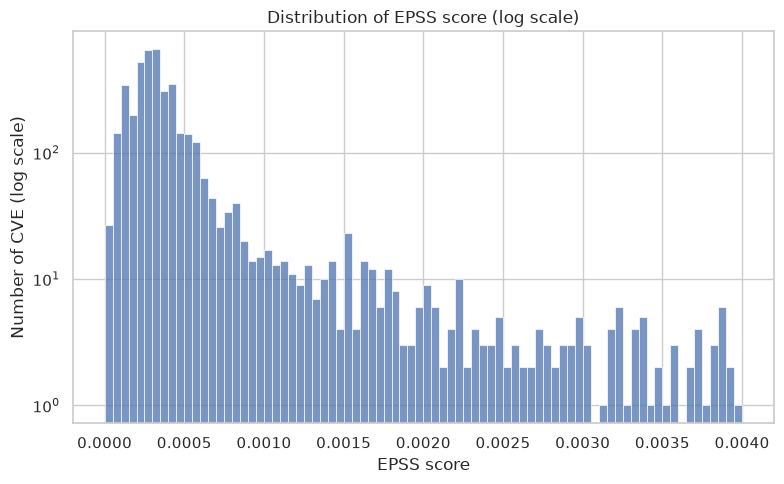

In [76]:

print("Severities:")
base_severities = df["cvss_baseSeverity"].value_counts()
print(base_severities)
print("-------------------------")

print("EPSS score statistics:")
print(df["epss"].describe())

print("-------------------------")
print("Number of CVEs with EPSS score:")
n_with_epss = df["epss"].notna().sum()
n_total = len(df)
print(f"CVE with EPSS score: {n_with_epss} su {n_total} ({n_with_epss/n_total*100:.1f}%)")

plt.figure(figsize=(8, 5))
sns.histplot(df["epss"].dropna(), bins=30, binwidth=0.00005, binrange=(0, 0.004))
plt.yscale("log")
plt.xlabel("EPSS score")
plt.ylabel("Number of CVE (log scale)")
plt.title("Distribution of EPSS score (log scale)")
plt.tight_layout()
plt.show()

### Produce a scatter plot showing CVSS vs EPSS

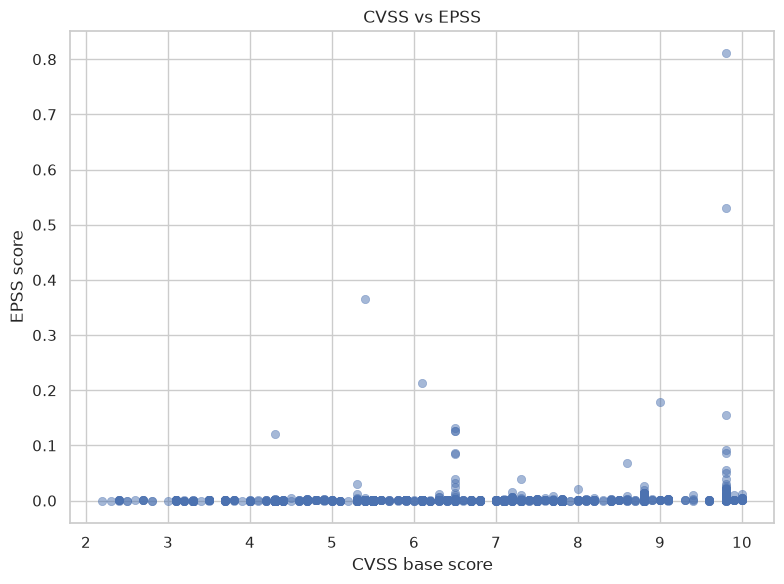

In [79]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="cvss_baseScore", y="epss", alpha=0.5, edgecolor=None)
plt.xlabel("CVSS base score")
plt.ylabel("EPSS score")
plt.title("CVSS vs EPSS")
plt.tight_layout()
plt.show()

# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


In [82]:
df_low_epss = df[df["epss"] < 0.01].copy()

print(f"{len(df_low_epss)} CVE of {len(df)} have EPSS < 1%")
df_low_epss.head()

4262 CVE of 4320 have EPSS < 1%


,cve.id,cve.sourceIdentifier,cve.published,cve.lastModified,cve.vulnStatus,cve.affected,cve.metrics.ssvcV203,cve.references,cve.cisaExploitAdd,cve.cisaActionDue,...,cvss_attackComplexity,cvss_privilegesRequired,cvss_userInteraction,cvss_scope,cvss_confidentialityImpact,cvss_integrityImpact,cvss_availabilityImpact,cve,epss,percentile
0,CVE-2025-9751,cna@vuldb.com,2025-09-01 00:15:34.580,2026-06-17 10:09:40.847,Analyzed,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,NaN,NaN,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,CVE-2025-9751,0.00030,0.07395
1,CVE-2025-9752,cna@vuldb.com,2025-09-01 01:15:46.817,2026-06-17 10:09:40.990,Analyzed,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'url': 'https://github.com/i-Corner/cve/issu...,NaN,NaN,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,CVE-2025-9752,0.00242,0.47575
2,CVE-2025-9753,cna@vuldb.com,2025-09-01 01:15:47.060,2026-06-17 10:09:41.133,Analyzed,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'url': 'https://github.com/Yashh-G/zero-day-...,NaN,NaN,...,LOW,HIGH,REQUIRED,CHANGED,LOW,LOW,NONE,CVE-2025-9753,0.00026,0.05727
3,CVE-2025-9754,cna@vuldb.com,2025-09-01 02:15:45.223,2026-06-17 10:09:41.280,Analyzed,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'url': 'https://github.com/Yashh-G/zero-day-...,NaN,NaN,...,LOW,LOW,REQUIRED,CHANGED,LOW,LOW,NONE,CVE-2025-9754,0.00028,0.06386
4,CVE-2025-9755,cna@vuldb.com,2025-09-01 02:15:45.493,2026-06-17 10:09:41.413,Analyzed,"[{'source': 'cna@vuldb.com', 'affectedData': [...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'url': 'https://gist.github.com/0xSebin/147e...,NaN,NaN,...,LOW,NONE,REQUIRED,CHANGED,LOW,LOW,NONE,CVE-2025-9755,0.00028,0.06393


In [ ]:
nickname = 'template_submsission' # TODO: put your nickname here


# TODO: put your selected IDs here
selected = ['CVE-YYYY-XXXXX0',
            'CVE-YYYY-XXXXX1',
            'CVE-YYYY-XXXXX2',
            'CVE-YYYY-XXXXX3',
            'CVE-YYYY-XXXXX4',
            'CVE-YYYY-XXXXX5',
            'CVE-YYYY-XXXXX6',
            'CVE-YYYY-XXXXX7',
            'CVE-YYYY-XXXXX8',
            'CVE-YYYY-XXXXX9',
           ]            

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))            